## Step 1  install and import Libraries 

In [22]:
# Install Tensorflow 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf 
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

print("TensorFLow version:", tf.__version__)
print("All libraries Loaded")

TensorFLow version: 2.21.0
All libraries Loaded


## Step 2 -- Configuration 

In [23]:
# Update THESE to match your CSV file 

CSV_PATH = 'Churn_Modelling.csv'    # path to your csv file 
TARGET_COL ='Exited'         # name of your binary target column(0 or 1)

# Leave as None to use ALL columns except target 
# Or list specific columns :["pressure", 'temperature', 'vibration']

FEATURE_COLS = None 

# Training settings 
TEST_SIZE =0.2

# 20% of data held out for testting 
EPOCH        = 10             # how many times the model sees the full dataset
BATCH_SIZE   =64              # samples per weight update 
LEARNNG_RATE =0.001           # Step size for gradient descent

print("Config set")


Config set


## Step 3 Load and Explore The Data 

In [24]:
# Load the csv file into a pandas dataframe 
df = pd.read_csv(CSV_PATH)

# Show the first 5 rows adand see what we are working with 
print('shape:', df.shape)  # (rows, columns)
df.head()

shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
# Check for missing values - the ANN cannot handle missing values 
print('Missing Values per columns:')
print(df.isnull().sum())

# check the class balance - how many failures vs normal 
print('\nTarget distribution:')
print(df[TARGET_COL].value_counts())

Missing Values per columns:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

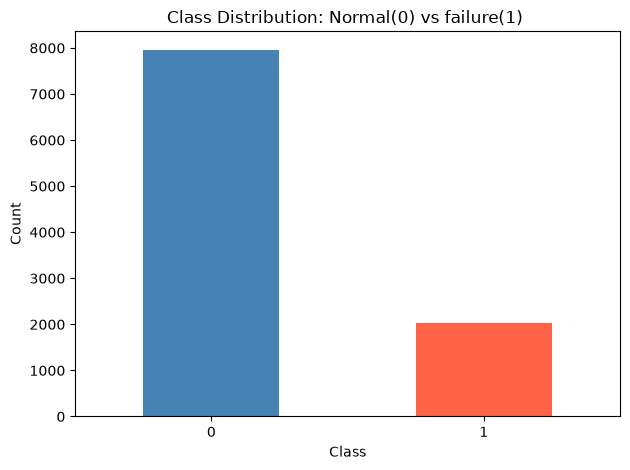

In [26]:
# Visulaize Class balance as a bar chart 
df[TARGET_COL].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title("Class Distribution: Normal(0) vs failure(1) ")
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show

## Step 4 -- Prepare fetaures and Target 


In [27]:
df = pd.get_dummies(df, columns= ['Geography'], drop_first=True)

df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})


In [28]:
# Seperate features (X) from the target label (y)

if FEATURE_COLS is None:
    # Use all columns except the target column
    X = df.drop(columns=[TARGET_COL,'RowNumber','CustomerId','Surname',])

else:
    # Use only the columns we specified
    X = df[FEATURE_COLS]

# Target variable - what we want to predict 
y = df[TARGET_COL]

print('Feature Shape:', X.shape)  #(samples, features)
print('Target shape:', y.shape)   #(target)
print('\nFeature columns:', list(X.columns))

Feature Shape: (10000, 11)
Target shape: (10000,)

Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


## Step 5 -- Split into Train and Test sets 


In [29]:
# Split Before Normalizing - this prevents data leakage 
# Random state = 42 makes the split reproducible (same results every run)

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42, stratify=y) # Keeps class balance equal in both splits 

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

Training samples: 8000
Test samples:     2000


In [30]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Step 6 -- Normalize the features 

In [31]:
# Scale all features to the range[0,1]
# This stops large-valued features from dominating small-valued ones 

scaler = MinMaxScaler()

#IMPORTANT: fit only on training data, then apply to both sets 
#Fitting on test data would be data leakage

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalization done")
print("Train Min/max after scaling:", X_train.min().round(2), "/", X_train.max().round(2))

Normalization done
Train Min/max after scaling: 0.0 / 1.0


## Step 7 -- Build the Neural network

In [32]:
# Get the nUmber of input features automatically from the data
n_features = X_train.shape[1]

# Build the model layer by layer using the Sequential API
model = Sequential([
    # Input + first hidden layer
    # units=64: 64 neurons in this layer 
    # activation ='relu': ReLU activation - best default for hidden layers 
    # input shape: tells keras the number features coming in 
    Dense(64, activation='relu', input_shape=(n_features,)),

    # Dropout: randomly switch off 30% of neurons during training 
    # prevents the model from memorizing the training data(overfitting)
    Dropout(0.3),

    # Second hidden layer - learns more complex combinations
    Dense(32, activation='relu'),

    # Another dropout layer for regularization
    Dropout(0.2),

    # Output layer - 1 neuron for binary classification
    # sigmoid squashes output to a probability between 0 and 1
    Dense(1, activation='sigmoid')
])

# Print a summary of the model perfomance
model.summary()

c:\Users\USER\Control\day1\Exclusive\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8 -- Compile The Model

In [33]:
# Compile : set the optimizer , loss function and the evaluation metric 

model.compile(
    # Adam optimizer - adapts learning rate automatically 
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNNG_RATE),

    # Binary Crossentropy -correct loss for 0/1 Classification
    loss= 'binary_crossentropy',
    
    # Accuracy - the % of correct predictions we will track 
    metrics=['accuracy']
)

print('Model Compiled')

Model Compiled


## Step 9 _ Train the Model 

In [34]:
# Early Stopping : Stop training if validation loss doesnt improve 
# Patience = 10 means wait 10 epochs before giving up 
# restore best weights brings back the best model seen during training 

early_stop= EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
# validation_split =0.15 uses 15% of training data to monitor overfitting 
history= model.fit(
    X_train, y_train,
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1 # print progress each epoch
)

print('\nTraining complete')

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7851 - loss: 0.5230 - val_accuracy: 0.8067 - val_loss: 0.4631
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7954 - loss: 0.4798 - val_accuracy: 0.8092 - val_loss: 0.4433
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7990 - loss: 0.4635 - val_accuracy: 0.8117 - val_loss: 0.4354
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8015 - loss: 0.4545 - val_accuracy: 0.8208 - val_loss: 0.4287
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8065 - loss: 0.4438 - val_accuracy: 0.8267 - val_loss: 0.4228
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8118 - loss: 0.4444 - val_accuracy: 0.8292 - val_loss: 0.4173
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8128 - loss: 0.4342 - val_accuracy: 0.8342 - val_loss: 0.4092
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8219 - loss: 0.4286 - val_accuracy: 0.

## Step 10 --Plot Training History 


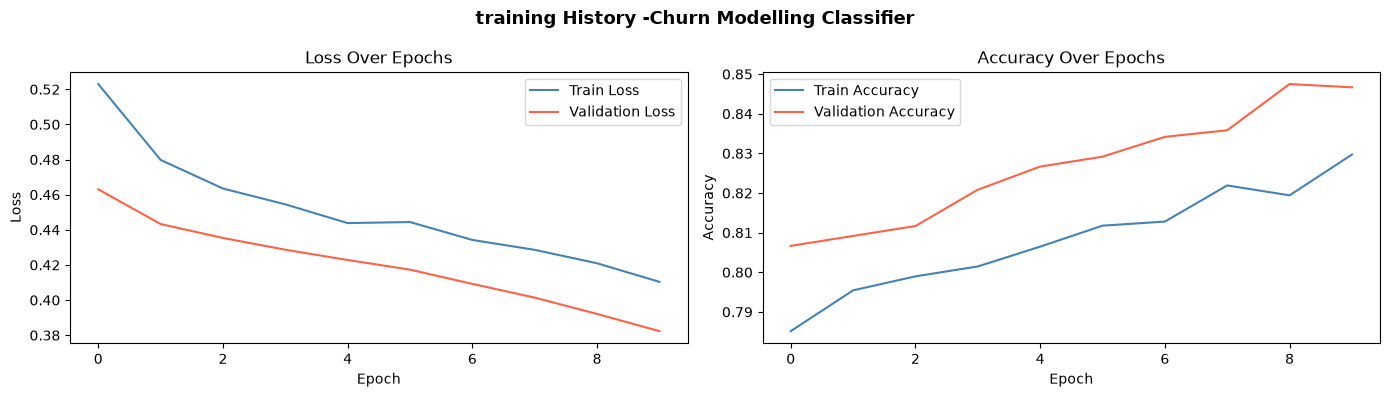

In [35]:
# Plot Loss and Accuracy curves side by side 
fig, axes = plt.subplots(1,2,figsize=(14,4))

# Loss Curve 
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy Curve 
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('training History -Churn Modelling Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# what to look for :
# Both curves should increase/decrease together 
# if train improves but val gets worse = overfitting


##  Step 11 -- Evaluate on the Test Set 

In [36]:
# Evaluate on the test set-data the model has NEVER seen
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy*100:.2f}')

Test Loss: 0.3933
Test accuracy: 83.65


In [37]:
# Get Predictions on the test set
# model.predict returns probabilities (0.0 to 1.0)
y_pred_probs = model.predict(X_test)

# convert probabilities to class labels 
# Anything above 0.5 =failure (1) below 0.5 = normal(0)
y_pred =(y_pred_probs>= 0.5).astype(int).flatten()

# detailed Performance report 
print('Classification report')
print(classification_report(y_test, y_pred, target_names=['Normal','Failure']))
print('accuracy:', test_accuracy)
# Precision : of all predicted failures, how many are real 
# Recall: of all real failures, how many did we catch 
# F1-score: balnce between precision and recall

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification report
              precision    recall  f1-score   support

      Normal       0.84      0.98      0.91      1593
     Failure       0.81      0.26      0.39       407

    accuracy                           0.84      2000
   macro avg       0.82      0.62      0.65      2000
weighted avg       0.83      0.84      0.80      2000

accuracy: 0.8364999890327454


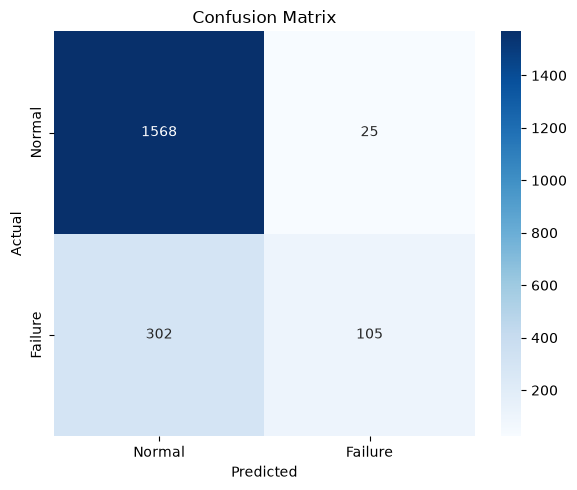

In [38]:
# confusion matrix - visual breakdown of corrct vs wrong prediction

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',    #integer format 
    cmap='Blues',
    xticklabels=['Normal','Failure'],
    yticklabels=['Normal','Failure']
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Top-Left : True Negatives (correctly predicted Normal)
# Top-Right: False positives (predicted failure, was actually normal)
# Bot-Left: False negatives (predicted normal, was actually failure) (costly)
# Bot-Right; True positives (correctly predicted failure)


## Step 12 -- Make a Single Prediction

In [39]:
# Predict on a single new sample 
# Replace thes values with one row from your dataset
new_reading =np.array([[4850,178,2.3,1240,320,43,65,78,444,66,0.77777]])

# Normalize using the same scaler fitted on training the data
new_reading_scaled = scaler.transform(new_reading)

# Get Probability of failure 
failure_prob = model.predict(new_reading_scaled)[0][0]

print(f"Churn Probability:  {failure_prob * 100:.1f}%")
print(f"Prediction : {'Churn risk' if failure_prob>=0.5 else 'Normal'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Churn Probability:  0.0%
Prediction : Normal


c:\Users\USER\Control\day1\Exclusive\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## Step 13 -- Save the Model

In [40]:
# Save the trained model so you can load it later without retraining 
model.save('Churn_Classifier.h5')
print('Model Saved')

# To load it later:
loaded_model = tf.keras.models.load_model('Churn_Classifier.h5')

Model Saved
